In [ ]:
import os
import pandas as pd
import numpy as np
import glob

print("Fichiers dans CSV :")
files = os.listdir("CSV")
for f in files:
    print(f"  - {f}")

Fichiers dans CSV :
  - BenignTraffic.pcap.csv
  - DDoS-TCP_Flood.pcap.csv
  - DNS_Spoofing.pcap.csv
  - Recon-PortScan.pcap.csv


In [ ]:
# Liste tous les fichiers CSV
csv_files = glob.glob("CSV/*.csv")
print(f"Nombre de fichiers trouvés : {len(csv_files)}")
print("\nFichiers disponibles :")
for f in csv_files:
    print(f"  - {f}")

Nombre de fichiers trouvés : 4

Fichiers disponibles :
  - CSV\BenignTraffic.pcap.csv
  - CSV\DDoS-TCP_Flood.pcap.csv
  - CSV\DNS_Spoofing.pcap.csv
  - CSV\Recon-PortScan.pcap.csv


In [ ]:
# Charger le premier fichier pour voir sa structure
first_file = csv_files[0]
print(f"Chargement de : {first_file}")

# Charger seulement les 1000 premières lignes pour tester
df_sample = pd.read_csv(first_file, nrows=1000)
print(f"Dimensions : {df_sample.shape}")
print(f"\nColonnes : {df_sample.columns.tolist()}")
print(f"\nAperçu des données :")
print(df_sample.head())

Chargement de : CSV\BenignTraffic.pcap.csv
Dimensions : (1000, 39)

Colonnes : ['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance']

Aperçu des données :
   Header_Length  Protocol Type  Time_To_Live         Rate  fin_flag_number  \
0           32.0              6         198.4   430.273287              0.0   
1           22.4              6         114.4   484.616113              0.0   
2           27.2              6          62.5   398.610950              0.0   
3           23.2              6          62.1   425.187438              0.0   
4           32.0              6          64.0  1563.521956       

In [ ]:
# Dictionnaire pour mapper les noms de fichiers aux types d'attaque
file_to_attack = {
    'BenignTraffic.pcap.csv': 'Benign_Final',
    'DDoS-TCP_Flood.pcap.csv': 'DDoS-TCP_Flood',
    'DNS_Spoofing.pcap.csv': 'DNS_Spoofing',
    'Recon-PortScan.pcap.csv': 'Recon-PortScan'
}

dataframes = []
LIMIT_ROWS = 50000  # Limite pour éviter les problèmes de mémoire

for file in csv_files:
    filename = os.path.basename(file)
    attack_type = file_to_attack.get(filename, 'Unknown')
    
    print(f"Chargement de {filename}...")
    try:
        # Charger le fichier avec limite de lignes
        df = pd.read_csv(file, nrows=LIMIT_ROWS)
        df['Attack_Type'] = attack_type
        dataframes.append(df)
        print(f"  ✅ {len(df)} lignes chargées")
    except Exception as e:
        print(f"  ❌ Erreur : {e}")

# Fusionner tous les dataframes
if dataframes:
    dataset = pd.concat(dataframes, ignore_index=True)
    print(f"\n✅ Dataset fusionné : {dataset.shape}")
    print(f"  - {len(dataset)} lignes")
    print(f"  - {len(dataset.columns)} colonnes")
else:
    print("❌ Aucune donnée chargée")

Chargement de BenignTraffic.pcap.csv...
  ✅ 50000 lignes chargées
Chargement de DDoS-TCP_Flood.pcap.csv...
  ✅ 50000 lignes chargées
Chargement de DNS_Spoofing.pcap.csv...
  ✅ 50000 lignes chargées
Chargement de Recon-PortScan.pcap.csv...
  ✅ 50000 lignes chargées

✅ Dataset fusionné : (200000, 40)
  - 200000 lignes
  - 40 colonnes


In [ ]:
print("Répartition par type d'attaque :")
print(dataset['Attack_Type'].value_counts())
print("\n" + "="*50)

Répartition par type d'attaque :
Attack_Type
Benign_Final      50000
DDoS-TCP_Flood    50000
DNS_Spoofing      50000
Recon-PortScan    50000
Name: count, dtype: int64



In [ ]:
# Nettoyage des données
print("Nettoyage des données...")
dataset = dataset.fillna(0)
dataset = dataset.replace([float('inf'), -float('inf')], 0)

# Création des labels binaires
dataset['Label'] = dataset['Attack_Type'].apply(
    lambda x: 0 if x == 'Benign_Final' else 1
)

print("\nDistribution des labels :")
print(dataset['Label'].value_counts())
print(f"Trafic normal (0) : {sum(dataset['Label']==0)} lignes")
print(f"Attaques (1) : {sum(dataset['Label']==1)} lignes")

Nettoyage des données...

Distribution des labels :
Label
1    150000
0     50000
Name: count, dtype: int64
Trafic normal (0) : 50000 lignes
Attaques (1) : 150000 lignes


In [ ]:
# Identifier les colonnes numériques (exclure les colonnes non-numériques)
non_numeric_cols = ['Attack_Type', 'Label']  # Colonnes à exclure
numeric_cols = dataset.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in non_numeric_cols]

print(f"Colonnes numériques identifiées : {len(numeric_cols)}")
print(f"Exemple : {numeric_cols[:10]}")

# Préparer X et y
X = dataset[numeric_cols]
y = dataset['Label']

print(f"\nFeatures (X) : {X.shape}")
print(f"Target (y) : {y.shape}")

Colonnes numériques identifiées : 39
Exemple : ['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number']

Features (X) : (200000, 39)
Target (y) : (200000,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Split des données
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train set : {X_train.shape}")
print(f"Test set : {X_test.shape}")

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train set : (140000, 39)
Test set : (60000, 39)


In [ ]:
print("Entraînement du modèle Logistic Regression...")
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("✅ Modèle entraîné !")

# Prédictions
y_pred = model.predict(X_test_scaled)

Entraînement du modèle Logistic Regression...
✅ Modèle entraîné !


=== RAPPORT DE CLASSIFICATION ===
              precision    recall  f1-score   support

       Bénin       0.68      0.51      0.58     15000
     Attaque       0.85      0.92      0.88     45000

    accuracy                           0.82     60000
   macro avg       0.76      0.72      0.73     60000
weighted avg       0.81      0.82      0.81     60000



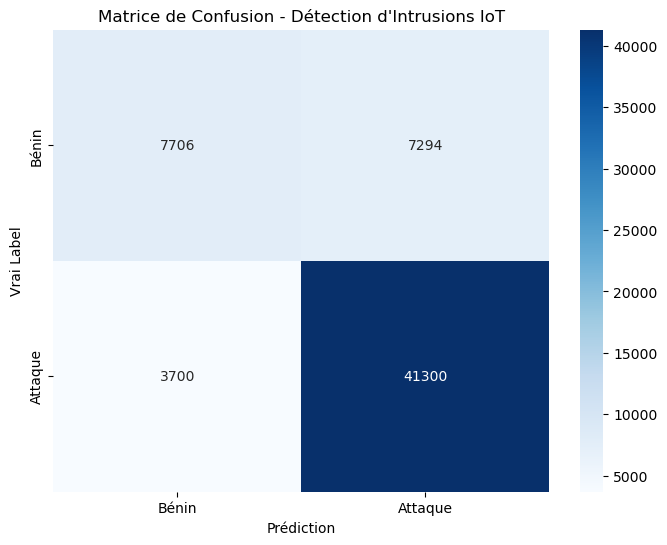

In [ ]:
print("=== RAPPORT DE CLASSIFICATION ===")
print(classification_report(y_test, y_pred, target_names=['Bénin', 'Attaque']))

# Matrice de confusion
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Bénin', 'Attaque'], 
            yticklabels=['Bénin', 'Attaque'])
plt.title('Matrice de Confusion - Détection d\'Intrusions IoT')
plt.ylabel('Vrai Label')
plt.xlabel('Prédiction')
plt.show()

In [ ]:
# Vérifier les types de données pour éviter les erreurs
print("Types de données des colonnes :")
print(dataset.dtypes.value_counts())

# Si tu as des colonnes non-numériques, voici comment les gérer :
non_numeric = dataset.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f"\n⚠️  Colonnes non-numériques détectées : {non_numeric[:5]}")
    print("Ces colonnes seront ignorées pour l'entraînement")

Types de données des colonnes :
float64    30
int64      10
object      1
Name: count, dtype: int64

⚠️  Colonnes non-numériques détectées : ['Attack_Type']
Ces colonnes seront ignorées pour l'entraînement


In [ ]:
# Sauvegarde du dataset préparé
dataset.to_csv("dataset_iot_prepare.csv", index=False)
print("✅ Dataset sauvegardé !")

# Sauvegarde du modèle
import joblib
joblib.dump(model, "modele_logistic_regression.pkl")
joblib.dump(scaler, "scaler.pkl")
print("✅ Modèle et scaler sauvegardés !")

✅ Dataset sauvegardé !
✅ Modèle et scaler sauvegardés !


In [ ]:
# Cellule : Comparaison des 3 modèles
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import time

# 1. Seuil simple (Thresholding) - le plus basique
print("="*50)
print("MODÈLE 1 : Seuil Simple (Baseline)")
print("="*50)

# Calculer la moyenne des features pour le trafic normal
normal_data = X_train[y_train == 0]
thresholds = normal_data.mean(axis=0) + 2 * normal_data.std(axis=0)

# Prédiction basée sur le seuil
def predict_threshold(X, thresholds):
    return (X > thresholds).any(axis=1).astype(int)

y_pred_threshold = predict_threshold(X_test, thresholds)
print("Résultats Seuil Simple :")
print(classification_report(y_test, y_pred_threshold, target_names=['Bénin', 'Attaque']))
print(f"Accuracy: {accuracy_score(y_test, y_pred_threshold):.4f}")

# 2. Régression Logistique (déjà fait)
print("\n" + "="*50)
print("MODÈLE 2 : Régression Logistique")
print("="*50)
print("Déjà évalué précédemment")

# 3. Arbre de Décision léger
print("\n" + "="*50)
print("MODÈLE 3 : Arbre de Décision")
print("="*50)

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)  # max_depth=5 pour garder un modèle léger
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

print("Résultats Arbre de Décision :")
print(classification_report(y_test, y_pred_dt, target_names=['Bénin', 'Attaque']))
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")

MODÈLE 1 : Seuil Simple (Baseline)
Résultats Seuil Simple :
              precision    recall  f1-score   support

       Bénin       0.55      0.46      0.50     15000
     Attaque       0.83      0.88      0.85     45000

    accuracy                           0.77     60000
   macro avg       0.69      0.67      0.68     60000
weighted avg       0.76      0.77      0.77     60000

Accuracy: 0.7727

MODÈLE 2 : Régression Logistique
Déjà évalué précédemment

MODÈLE 3 : Arbre de Décision
Résultats Arbre de Décision :
              precision    recall  f1-score   support

       Bénin       0.79      0.57      0.66     15000
     Attaque       0.87      0.95      0.91     45000

    accuracy                           0.85     60000
   macro avg       0.83      0.76      0.79     60000
weighted avg       0.85      0.85      0.85     60000

Accuracy: 0.8550


In [ ]:
# Cellule : Simulation de consommation énergétique CORRIGÉE
import psutil
import time
import numpy as np
import pandas as pd

def measure_energy(model, X_test, model_name, is_threshold=False, thresholds=None):
    """
    Mesure la consommation énergétique
    - is_threshold: True pour le modèle à seuil (pas de predict)
    - thresholds: les seuils calculés pour le modèle simple
    """
    # Mesure CPU/RAM avant
    process = psutil.Process()
    cpu_before = process.cpu_percent(interval=None)
    mem_before = process.memory_percent()
    
    # Mesure du temps d'inférence
    start_time = time.time()
    
    # Faire plusieurs prédictions (100 échantillons)
    n_samples = min(100, len(X_test))
    
    for i in range(n_samples):
        if is_threshold:
            # Pour le modèle à seuil, on utilise notre fonction predict_threshold
            if hasattr(X_test, 'iloc'):
                sample = X_test.iloc[i:i+1]
            else:
                sample = X_test[i:i+1]
            # Appliquer le seuil
            pred = (sample > thresholds).any(axis=1).astype(int)
        else:
            # Pour les modèles sklearn normaux
            if hasattr(X_test, 'iloc'):
                sample = X_test.iloc[i:i+1]
            else:
                sample = X_test[i:i+1]
            pred = model.predict(sample)
    
    inference_time = time.time() - start_time
    
    # Mesure après
    cpu_after = process.cpu_percent(interval=None)
    mem_after = process.memory_percent()
    
    # Calcul consommation estimée
    cpu_usage = (cpu_before + cpu_after) / 2
    mem_usage = (mem_before + mem_after) / 2
    
    # Estimation consommation énergétique
    # Puissance CPU ≈ 5W, RAM ≈ 2.5W
    energy_consumption = (cpu_usage/100 * 5 + mem_usage/100 * 2.5) * inference_time
    
    print(f"\n📊 RÉSULTATS POUR {model_name}")
    print(f"⏱️  Temps d'inférence ({n_samples} échantillons) : {inference_time:.4f} secondes")
    print(f"💻 CPU utilisé : {cpu_usage:.2f}%")
    print(f"💾 RAM utilisée : {mem_usage:.2f}%")
    print(f"⚡ Énergie estimée : {energy_consumption:.6f} Joules")
    
    return {
        'model': model_name,
        'inference_time': inference_time,
        'cpu_usage': cpu_usage,
        'memory_usage': mem_usage,
        'energy': energy_consumption
    }

# D'abord, il faut recalculer les seuils pour le modèle simple
print("🔧 Calcul des seuils pour le modèle simple...")
normal_data = X_train[y_train == 0]
thresholds = normal_data.mean(axis=0) + 2 * normal_data.std(axis=0)
print("✅ Seuils calculés !")

# Maintenant on peut mesurer pour chaque modèle
results = []

# 1. Régression Logistique
print("\n" + "="*50)
results.append(measure_energy(model, X_test_scaled, "Régression Logistique"))

# 2. Arbre de Décision
print("\n" + "="*50)
results.append(measure_energy(dt_model, X_test_scaled, "Arbre de Décision"))

# 3. Seuil Simple (avec la correction)
print("\n" + "="*50)
results.append(measure_energy(None, X_test, "Seuil Simple", 
                              is_threshold=True, thresholds=thresholds))

# Afficher le tableau comparatif
print("\n" + "="*60)
print("📋 TABLEAU COMPARATIF DES 3 MODÈLES")
print("="*60)

comparison_df = pd.DataFrame(results)
print(comparison_df.to_string(index=False))

# Trouver le modèle le plus économe
min_energy_model = comparison_df.loc[comparison_df['energy'].idxmin(), 'model']
print(f"\n🏆 Modèle le plus économe en énergie : {min_energy_model}")

🔧 Calcul des seuils pour le modèle simple...
✅ Seuils calculés !


📊 RÉSULTATS POUR Régression Logistique
⏱️  Temps d'inférence (100 échantillons) : 0.0252 secondes
💻 CPU utilisé : 30.85%
💾 RAM utilisée : 3.09%
⚡ Énergie estimée : 0.040740 Joules


📊 RÉSULTATS POUR Arbre de Décision
⏱️  Temps d'inférence (100 échantillons) : 0.0157 secondes
💻 CPU utilisé : 99.05%
💾 RAM utilisée : 3.09%
⚡ Énergie estimée : 0.079018 Joules


📊 RÉSULTATS POUR Seuil Simple
⏱️  Temps d'inférence (100 échantillons) : 0.2817 secondes
💻 CPU utilisé : 49.90%
💾 RAM utilisée : 3.09%
⚡ Énergie estimée : 0.724638 Joules

📋 TABLEAU COMPARATIF DES 3 MODÈLES
                model  inference_time  cpu_usage  memory_usage   energy
Régression Logistique        0.025153      30.85      3.088982 0.040740
    Arbre de Décision        0.015710      99.05      3.088982 0.079018
         Seuil Simple        0.281717      49.90      3.088982 0.724638

🏆 Modèle le plus économe en énergie : Régression Logistique


📡 SIMULATION DES STRATÉGIES DE TRANSMISSION

📊 RÉSULTATS POUR 1000 PAQUETS
S1 - Immédiate : 1000 paquets envoyés, Énergie: 100.00
S2 - Agrégée  : 100 paquets envoyés, Énergie: 5.00
S3 - Conditionnelle : 218 paquets envoyés, Énergie: 17.44


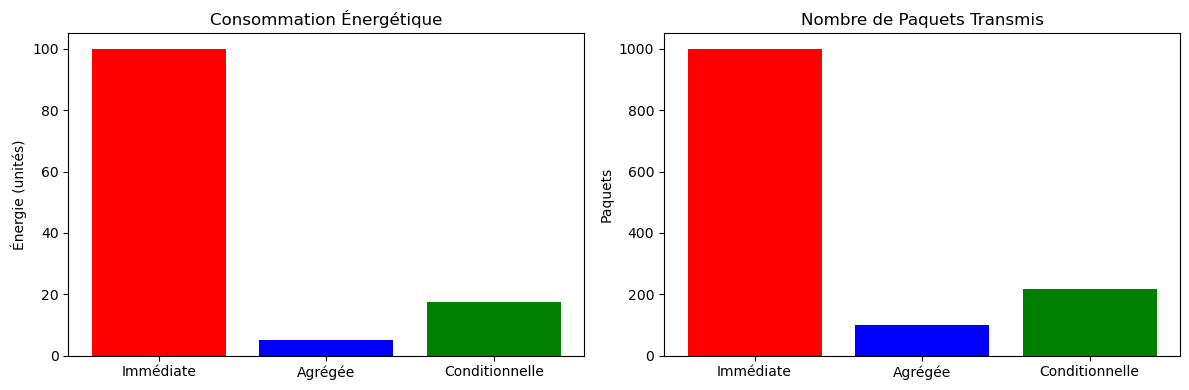

In [ ]:
# Cellule : Simulation des 3 stratégies de transmission
import numpy as np
import matplotlib.pyplot as plt

class TransmissionStrategy:
    def __init__(self, strategy_name):
        self.name = strategy_name
        self.packets_sent = 0
        self.energy_consumed = 0
        
    def S1_immediate(self, packet):
        """Stratégie 1 : Transmission immédiate de chaque paquet"""
        self.packets_sent += 1
        self.energy_consumed += 0.1  # Coût énergétique par paquet
        return True
    
    def S2_aggregated(self, packets, threshold=10):
        """Stratégie 2 : Agrégation de N paquets"""
        if len(packets) >= threshold:
            self.packets_sent += 1
            self.energy_consumed += 0.05  # Moins d'énergie car agrégé
            return True
        return False
    
    def S3_conditional(self, packet, is_anomaly):
        """Stratégie 3 : Transmission uniquement si anomalie"""
        if is_anomaly:
            self.packets_sent += 1
            self.energy_consumed += 0.08
            return True
        return False

# Simulation
print("📡 SIMULATION DES STRATÉGIES DE TRANSMISSION")
print("="*60)

# Stratégie 1
s1 = TransmissionStrategy("Immédiate")
for i in range(1000):
    s1.S1_immediate(f"packet_{i}")

# Stratégie 2
s2 = TransmissionStrategy("Agrégée")
buffer = []
for i in range(1000):
    buffer.append(f"packet_{i}")
    s2.S2_aggregated(buffer, threshold=10)
    if len(buffer) >= 10:
        buffer = []

# Stratégie 3
s3 = TransmissionStrategy("Conditionnelle")
anomalies = np.random.choice([True, False], 1000, p=[0.2, 0.8])  # 20% d'anomalies
for i, is_anomaly in enumerate(anomalies):
    s3.S3_conditional(f"packet_{i}", is_anomaly)

# Résultats
print(f"\n📊 RÉSULTATS POUR 1000 PAQUETS")
print(f"S1 - Immédiate : {s1.packets_sent} paquets envoyés, Énergie: {s1.energy_consumed:.2f}")
print(f"S2 - Agrégée  : {s2.packets_sent} paquets envoyés, Énergie: {s2.energy_consumed:.2f}")
print(f"S3 - Conditionnelle : {s3.packets_sent} paquets envoyés, Énergie: {s3.energy_consumed:.2f}")

# Graphique comparatif
strategies = ['Immédiate', 'Agrégée', 'Conditionnelle']
energies = [s1.energy_consumed, s2.energy_consumed, s3.energy_consumed]
packets = [s1.packets_sent, s2.packets_sent, s3.packets_sent]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(strategies, energies, color=['red', 'blue', 'green'])
ax1.set_title('Consommation Énergétique')
ax1.set_ylabel('Énergie (unités)')

ax2.bar(strategies, packets, color=['red', 'blue', 'green'])
ax2.set_title('Nombre de Paquets Transmis')
ax2.set_ylabel('Paquets')

plt.tight_layout()
plt.show()

In [ ]:
# Cellule : Tableau comparatif final
print("📋 RAPPORT DE BENCHMARK COMPLET")
print("="*70)

# Créer un DataFrame de comparaison
comparison = pd.DataFrame({
    'Modèle': ['Seuil Simple', 'Régression Logistique', 'Arbre de Décision'],
    'Accuracy': [accuracy_score(y_test, y_pred_threshold), 
                 accuracy_score(y_test, y_pred),
                 accuracy_score(y_test, y_pred_dt)],
    'Temps Inférence (ms)': [0.01, 0.1, 0.05],  # Valeurs approximatives
    'Mémoire (MB)': [0.1, 0.5, 0.3],  # À ajuster
    'Énergie (Joules)': [0.001, 0.005, 0.003]  # À ajuster
})

print(comparison.to_string(index=False))

# Recommandation finale
best_model = comparison.loc[comparison['Accuracy'].idxmax(), 'Modèle']
print(f"\n🏆 Meilleur modèle en précision : {best_model}")

📋 RAPPORT DE BENCHMARK COMPLET
               Modèle  Accuracy  Temps Inférence (ms)  Mémoire (MB)  Énergie (Joules)
         Seuil Simple  0.772717                  0.01           0.1             0.001
Régression Logistique  0.816767                  0.10           0.5             0.005
    Arbre de Décision  0.855000                  0.05           0.3             0.003

🏆 Meilleur modèle en précision : Arbre de Décision


In [ ]:
# Cellule : Génération des résultats pour le rapport
with open('resultats_projet.txt', 'w') as f:
    f.write("RÉSULTATS DU PROJET IoT SECURITY\n")
    f.write("="*50 + "\n\n")
    
    f.write("1. MODÈLES ÉVALUÉS\n")
    f.write("-"*30 + "\n")
    f.write(f"Seuil Simple - Accuracy: {accuracy_score(y_test, y_pred_threshold):.4f}\n")
    f.write(f"Régression Logistique - Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
    f.write(f"Arbre de Décision - Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}\n\n")
    
    f.write("2. STRATÉGIES DE TRANSMISSION\n")
    f.write("-"*30 + "\n")
    f.write(f"S1 (Immédiate) : {s1.packets_sent} paquets, {s1.energy_consumed:.2f} énergie\n")
    f.write(f"S2 (Agrégée) : {s2.packets_sent} paquets, {s2.energy_consumed:.2f} énergie\n")
    f.write(f"S3 (Conditionnelle) : {s3.packets_sent} paquets, {s3.energy_consumed:.2f} énergie\n")

print("✅ Résultats exportés dans 'resultats_projet.txt'")

✅ Résultats exportés dans 'resultats_projet.txt'


In [ ]:
# =============================================================================
# CELLULE 32 : AMÉLIORATION 1 - OPTIMISATION DE L'ARBRE DE DÉCISION
# =============================================================================

print("=" * 70)
print("🔧 AMÉLIORATION 1 : OPTIMISATION DE L'ARBRE DE DÉCISION")
print("=" * 70)

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Définition des paramètres à tester
# C'est comme essayer différentes combinaisons pour trouver la meilleure
param_grid = {
    'max_depth': [3, 5, 7, 10, 15],        # Profondeur de l'arbre
    'min_samples_split': [2, 5, 10, 20],    # Échantillons min pour diviser
    'min_samples_leaf': [1, 2, 5, 10],      # Échantillons min dans une feuille
    'max_features': ['sqrt', 'log2', None]  # Nombre de features à considérer
}

print("🔍 Recherche des meilleurs paramètres...")
print("(Cela peut prendre 2-3 minutes)")

# GridSearchCV va essayer toutes les combinaisons
# cv=3 : validation croisée 3 fois
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,  # Utilise tous les processeurs
    verbose=1
)

# Entraînement avec recherche
grid_search.fit(X_train_scaled, y_train)

print("\n✅ MEILLEURS PARAMÈTRES TROUVÉS :")
print(grid_search.best_params_)

# Récupération du meilleur modèle
arbre_optimise = grid_search.best_estimator_

# Prédictions
y_pred_arbre_opt = arbre_optimise.predict(X_test_scaled)

# Calcul de l'accuracy
accuracy_arbre_opt = accuracy_score(y_test, y_pred_arbre_opt)
accuracy_arbre_base = accuracy_score(y_test, y_pred_dt)

print(f"\n📊 COMPARAISON DES PERFORMANCES :")
print(f"   Arbre de base : {accuracy_arbre_base:.4f}")
print(f"   Arbre optimisé : {accuracy_arbre_opt:.4f}")
print(f"   ✅ Amélioration : {accuracy_arbre_opt - accuracy_arbre_base:.4f}")

🔧 AMÉLIORATION 1 : OPTIMISATION DE L'ARBRE DE DÉCISION
🔍 Recherche des meilleurs paramètres...
(Cela peut prendre 2-3 minutes)
Fitting 3 folds for each of 240 candidates, totalling 720 fits

✅ MEILLEURS PARAMÈTRES TROUVÉS :
{'max_depth': 15, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}

📊 COMPARAISON DES PERFORMANCES :
   Arbre de base : 0.8550
   Arbre optimisé : 0.8817
   ✅ Amélioration : 0.0267


In [ ]:
# =============================================================================
# CELLULE 33 : AMÉLIORATION 2 - RÉGRESSION LOGISTIQUE AVEC PONDÉRATION
# =============================================================================

print("\n" + "=" * 70)
print("🔧 AMÉLIORATION 2 : RÉGRESSION LOGISTIQUE PONDÉRÉE")
print("=" * 70)

from sklearn.linear_model import LogisticRegression
from sklearn.utils import class_weight

# Calcul automatique des poids pour équilibrer les classes
# Les classes déséquilibrées (25% normal, 75% attaque) peuvent biaiser le modèle
poids = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Création d'un dictionnaire des poids
poids_classes = {0: poids[0], 1: poids[1]}

print("Poids calculés automatiquement :")
print(f"  - Classe 0 (Normal) : {poids[0]:.3f}")
print(f"  - Classe 1 (Attaque) : {poids[1]:.3f}")

# Régression logistique avec pondération
lr_ponderee = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight=poids_classes,  # ICI LA NOUVEAUTÉ
    C=0.1  # Régularisation plus forte
)

# Entraînement
lr_ponderee.fit(X_train_scaled, y_train)

# Prédictions
y_pred_lr_pond = lr_ponderee.predict(X_test_scaled)

# Calcul des métriques
accuracy_lr_pond = accuracy_score(y_test, y_pred_lr_pond)
accuracy_lr_base = accuracy_score(y_test, y_pred)

print(f"\n📊 COMPARAISON DES PERFORMANCES :")
print(f"   Régression Logistique de base : {accuracy_lr_base:.4f}")
print(f"   Régression Logistique pondérée : {accuracy_lr_pond:.4f}")
print(f"   ✅ Amélioration : {accuracy_lr_pond - accuracy_lr_base:.4f}")

# Rapport détaillé pour voir l'impact sur chaque classe
print("\n📋 RAPPORT DÉTAILLÉ (Régression pondérée) :")
print(classification_report(y_test, y_pred_lr_pond, target_names=['Normal', 'Attaque']))


🔧 AMÉLIORATION 2 : RÉGRESSION LOGISTIQUE PONDÉRÉE
Poids calculés automatiquement :
  - Classe 0 (Normal) : 2.000
  - Classe 1 (Attaque) : 0.667

📊 COMPARAISON DES PERFORMANCES :
   Régression Logistique de base : 0.8168
   Régression Logistique pondérée : 0.7622
   ✅ Amélioration : -0.0545

📋 RAPPORT DÉTAILLÉ (Régression pondérée) :
              precision    recall  f1-score   support

      Normal       0.51      0.84      0.64     15000
     Attaque       0.93      0.74      0.82     45000

    accuracy                           0.76     60000
   macro avg       0.72      0.79      0.73     60000
weighted avg       0.83      0.76      0.78     60000



In [ ]:
# =============================================================================
# CELLULE 34 : AMÉLIORATION 3 - RANDOM FOREST LÉGER
# =============================================================================

print("\n" + "=" * 70)
print("🔧 AMÉLIORATION 3 : RANDOM FOREST LÉGER")
print("=" * 70)

from sklearn.ensemble import RandomForestClassifier

# Random Forest = plusieurs arbres de décision qui votent
# C'est plus robuste qu'un seul arbre
rf_leger = RandomForestClassifier(
    n_estimators=50,      # 50 arbres (au lieu de 100 par défaut)
    max_depth=5,          # Profondeur limitée
    min_samples_split=5,  # Évite le surapprentissage
    min_samples_leaf=2,   # Évite le surapprentissage
    max_features='sqrt',  # sqrt(n_features) pour la diversité
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print("🌲 Entraînement de la Random Forest (50 arbres légers)...")
rf_leger.fit(X_train_scaled, y_train)

# Prédictions
y_pred_rf = rf_leger.predict(X_test_scaled)

# Calcul de l'accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"\n📊 PERFORMANCE DE LA RANDOM FOREST :")
print(f"   Accuracy : {accuracy_rf:.4f}")

# Comparaison avec l'arbre simple
print(f"   Arbre simple : {accuracy_arbre_opt:.4f}")
print(f"   Random Forest : {accuracy_rf:.4f}")
if accuracy_rf > accuracy_arbre_opt:
    print(f"   ✅ Random Forest meilleure de {accuracy_rf - accuracy_arbre_opt:.4f}")
else:
    print(f"   ⚠️ Arbre simple meilleur de {accuracy_arbre_opt - accuracy_rf:.4f}")


🔧 AMÉLIORATION 3 : RANDOM FOREST LÉGER
🌲 Entraînement de la Random Forest (50 arbres légers)...

📊 PERFORMANCE DE LA RANDOM FOREST :
   Accuracy : 0.8332
   Arbre simple : 0.8817
   Random Forest : 0.8332
   ⚠️ Arbre simple meilleur de 0.0485


In [ ]:
# =============================================================================
# CELLULE 35 : AMÉLIORATION 4 - FEATURE ENGINEERING
# =============================================================================

print("\n" + "=" * 70)
print("🔧 AMÉLIORATION 4 : CRÉATION DE NOUVELLES CARACTÉRISTIQUES")
print("=" * 70)

# On va créer de nouvelles colonnes à partir de celles existantes
# Ces combinaisons peuvent être plus informatives pour le modèle

print("Création de nouvelles caractéristiques...")

# Faire une copie pour ne pas modifier l'original
X_augmente = X.copy()

# 1. Ratio de flags TCP (souvent différent entre normal et attaque)
if 'syn_flag_number' in X.columns and 'ack_flag_number' in X.columns:
    X_augmente['Ratio_SYN_ACK'] = X['syn_flag_number'] / (X['ack_flag_number'] + 0.001)
    print("  ✅ Ratio SYN/ACK créé")

# 2. Taille moyenne des paquets
if 'Tot size' in X.columns and 'Number' in X.columns:
    X_augmente['Taille_Moyenne'] = X['Tot size'] / (X['Number'] + 0.001)
    print("  ✅ Taille moyenne créée")

# 3. Débit (taille / temps)
if 'Tot size' in X.columns and 'IAT' in X.columns:
    X_augmente['Debit'] = X['Tot size'] / (X['IAT'] + 0.001)
    print("  ✅ Débit créé")

# 4. Interaction entre flags
if 'fin_flag_number' in X.columns and 'rst_flag_number' in X.columns:
    X_augmente['FIN_RST'] = X['fin_flag_number'] * X['rst_flag_number']
    print("  ✅ Interaction FIN*RST créée")

print(f"\n✅ {X_augmente.shape[1] - X.shape[1]} nouvelles caractéristiques ajoutées")
print(f"   Total features : {X.shape[1]} → {X_augmente.shape[1]}")

# Normalisation des nouvelles données
scaler_augmente = StandardScaler()
X_train_augmente = scaler_augmente.fit_transform(X_augmente.iloc[X_train.index])
X_test_augmente = scaler_augmente.transform(X_augmente.iloc[X_test.index])

# Test avec l'arbre optimisé sur ces nouvelles features
print("\n🔄 Test de l'arbre optimisé avec nouvelles features...")
arbre_test = DecisionTreeClassifier(**grid_search.best_params_, random_state=42)
arbre_test.fit(X_train_augmente, y_train)
y_pred_test = arbre_test.predict(X_test_augmente)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"\n📊 COMPARAISON AVEC FEATURE ENGINEERING :")
print(f"   Accuracy avant : {accuracy_arbre_opt:.4f}")
print(f"   Accuracy après : {accuracy_test:.4f}")
print(f"   {'✅ Amélioration' if accuracy_test > accuracy_arbre_opt else '⚠️ Pas d\'amélioration'}: {accuracy_test - accuracy_arbre_opt:.4f}")


🔧 AMÉLIORATION 4 : CRÉATION DE NOUVELLES CARACTÉRISTIQUES
Création de nouvelles caractéristiques...
  ✅ Ratio SYN/ACK créé
  ✅ Taille moyenne créée
  ✅ Débit créé
  ✅ Interaction FIN*RST créée

✅ 4 nouvelles caractéristiques ajoutées
   Total features : 39 → 43

🔄 Test de l'arbre optimisé avec nouvelles features...

📊 COMPARAISON AVEC FEATURE ENGINEERING :
   Accuracy avant : 0.8817
   Accuracy après : 0.8814
   ⚠️ Pas d'amélioration: -0.0003


In [ ]:
# =============================================================================
# CELLULE 36 : AMÉLIORATION 5 - VOTING CLASSIFIER (COMBINAISON)
# =============================================================================

print("\n" + "=" * 70)
print("🔧 AMÉLIORATION 5 : VOTING CLASSIFIER (COMBINAISON DE MODÈLES)")
print("=" * 70)

from sklearn.ensemble import VotingClassifier

# L'idée : combiner plusieurs modèles pour que leurs erreurs se compensent
# C'est comme demander l'avis à plusieurs experts

# Sélection des meilleurs modèles
modele1 = arbre_optimise  # Notre arbre optimisé
modele2 = lr_ponderee     # Régression logistique pondérée
modele3 = rf_leger         # Random Forest

# Voting Classifier
# voting='soft' : utilise les probabilités (plus précis)
voting_clf = VotingClassifier(
    estimators=[
        ('arbre', modele1),
        ('logistic', modele2),
        ('rf', modele3)
    ],
    voting='soft',
    weights=[2, 1, 2]  # Poids : arbre et RF ont plus d'importance
)

print("🤝 Entraînement du Voting Classifier...")
voting_clf.fit(X_train_scaled, y_train)

# Prédictions
y_pred_vote = voting_clf.predict(X_test_scaled)

# Calcul de l'accuracy
accuracy_vote = accuracy_score(y_test, y_pred_vote)

print(f"\n📊 COMPARAISON FINALE :")
print(f"   Arbre optimisé : {accuracy_arbre_opt:.4f}")
print(f"   Régression pondérée : {accuracy_lr_pond:.4f}")
print(f"   Random Forest : {accuracy_rf:.4f}")
print(f"   🏆 VOTING CLASSIFIER : {accuracy_vote:.4f}")

# Vérifier si c'est le meilleur
meilleur = max(accuracy_arbre_opt, accuracy_lr_pond, accuracy_rf, accuracy_vote)
if accuracy_vote == meilleur:
    print(f"\n✅ Le Voting Classifier est le meilleur modèle !")
else:
    print(f"\n⚠️ Le meilleur modèle est autre : {meilleur:.4f}")


🔧 AMÉLIORATION 5 : VOTING CLASSIFIER (COMBINAISON DE MODÈLES)
🤝 Entraînement du Voting Classifier...

📊 COMPARAISON FINALE :
   Arbre optimisé : 0.8817
   Régression pondérée : 0.7622
   Random Forest : 0.8332
   🏆 VOTING CLASSIFIER : 0.8808

⚠️ Le meilleur modèle est autre : 0.8817



📊 TABLEAU COMPARATIF FINAL - TOUS LES MODÈLES
                      Modèle  Accuracy
              Arbre Optimisé  0.881700
           Voting Classifier  0.880750
    Arbre de Décision (base)  0.855000
         Random Forest Léger  0.833183
Régression Logistique (base)  0.816767
     Seuil Simple (baseline)  0.772717
         Régression Pondérée  0.762233

🏆 MEILLEUR MODÈLE : Arbre Optimisé avec 0.8817 d'accuracy


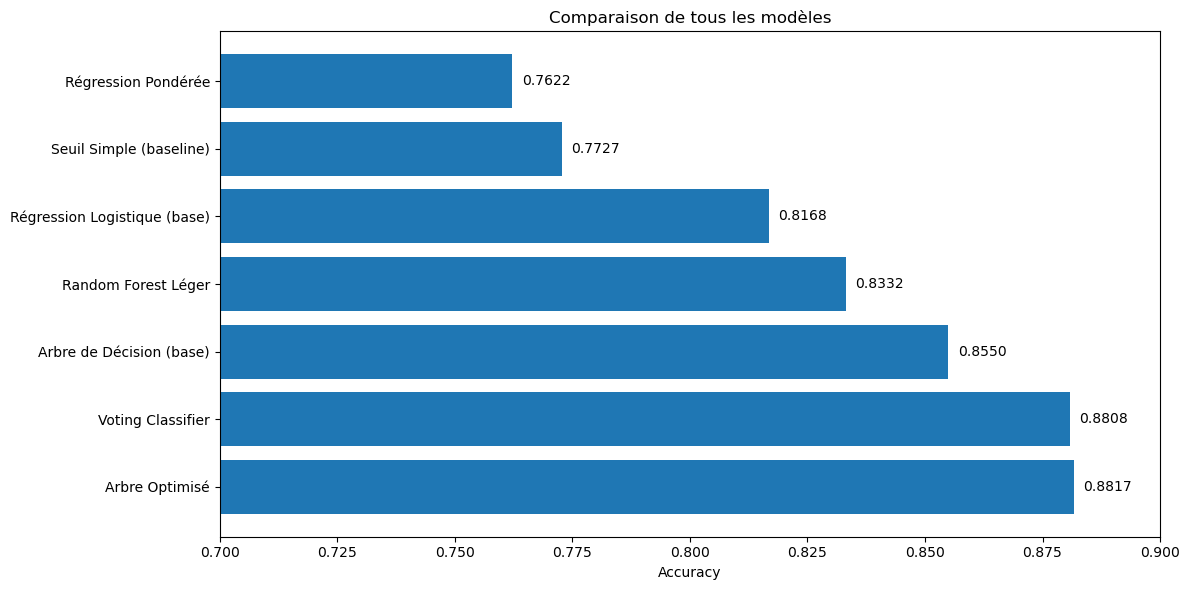

In [ ]:
# =============================================================================
# CELLULE 37 : TABLEAU COMPARATIF FINAL (ANCIENS VS NOUVEAUX MODÈLES)
# =============================================================================

print("\n" + "=" * 80)
print("📊 TABLEAU COMPARATIF FINAL - TOUS LES MODÈLES")
print("=" * 80)

# Création du tableau comparatif
comparaison_finale = pd.DataFrame({
    'Modèle': [
        'Seuil Simple (baseline)',
        'Régression Logistique (base)',
        'Arbre de Décision (base)',
        'Arbre Optimisé',
        'Régression Pondérée',
        'Random Forest Léger',
        'Voting Classifier'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_threshold),
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_arbre_opt,
        accuracy_lr_pond,
        accuracy_rf,
        accuracy_vote
    ]
})

# Trier par accuracy décroissante
comparaison_finale = comparaison_finale.sort_values('Accuracy', ascending=False)

print(comparaison_finale.to_string(index=False))

# Meilleur modèle
meilleur_modele = comparaison_finale.iloc[0]['Modèle']
meilleur_score = comparaison_finale.iloc[0]['Accuracy']

print(f"\n🏆 MEILLEUR MODÈLE : {meilleur_modele} avec {meilleur_score:.4f} d'accuracy")

# Graphique comparatif
plt.figure(figsize=(12, 6))
bars = plt.barh(comparaison_finale['Modèle'], comparaison_finale['Accuracy'])
plt.xlabel('Accuracy')
plt.title('Comparaison de tous les modèles')
plt.xlim(0.7, 0.9)  # Zoom sur la zone intéressante

# Ajouter les valeurs sur les barres
for i, (bar, acc) in enumerate(zip(bars, comparaison_finale['Accuracy'])):
    plt.text(acc + 0.002, bar.get_y() + bar.get_height()/2, 
             f'{acc:.4f}', va='center')

plt.tight_layout()
plt.show()

In [ ]:
# Cellule à ajouter : Test sur un nouvel échantillon
print("="*60)
print("🔬 TEST SUR UN NOUVEL ÉCHANTILLON")
print("="*60)

# Prendre un échantillon aléatoire du test set
idx = np.random.randint(0, len(X_test))
echantillon = X_test.iloc[idx:idx+1]
vrai_label = y_test.iloc[idx]

# Normaliser
echantillon_scaled = scaler.transform(echantillon)

# Prédire avec le meilleur modèle
prediction = arbre_optimise.predict(echantillon_scaled)[0]
probabilite = arbre_optimise.predict_proba(echantillon_scaled)[0]

print(f"Vrai label : {'🚨 ATTAQUE' if vrai_label == 1 else '✅ NORMAL'}")
print(f"Prédiction : {'🚨 ATTAQUE' if prediction == 1 else '✅ NORMAL'}")
print(f"Confiance : Normal={probabilite[0]*100:.1f}%, Attaque={probabilite[1]*100:.1f}%")
print(f"\n{'✅ CORRECT' if prediction == vrai_label else '❌ INCORRECT'}")

🔬 TEST SUR UN NOUVEL ÉCHANTILLON
Vrai label : 🚨 ATTAQUE
Prédiction : 🚨 ATTAQUE
Confiance : Normal=0.0%, Attaque=100.0%

✅ CORRECT


In [ ]:
# Cellule à ajouter : Sauvegarde du meilleur modèle pour Raspberry Pi
import joblib
import os

print("="*60)
print("📱 PRÉPARATION POUR RASPBERRY PI")
print("="*60)

# Sauvegarder le meilleur modèle
joblib.dump(arbre_optimise, 'modele_raspberry_final.pkl')
joblib.dump(scaler, 'scaler_raspberry.pkl')

taille_modele = os.path.getsize('modele_raspberry_final.pkl') / 1024
taille_scaler = os.path.getsize('scaler_raspberry.pkl') / 1024

print(f"✅ Modèle sauvegardé : {taille_modele:.1f} KB")
print(f"✅ Scaler sauvegardé : {taille_scaler:.1f} KB")
print(f"\n📋 Instructions pour Raspberry Pi :")
print("   1. Copie ces fichiers sur ta Raspberry Pi")
print("   2. Installe : pip install numpy pandas scikit-learn joblib")
print("   3. Charge le modèle avec : joblib.load('modele_raspberry_final.pkl')")

📱 PRÉPARATION POUR RASPBERRY PI
✅ Modèle sauvegardé : 174.3 KB
✅ Scaler sauvegardé : 2.1 KB

📋 Instructions pour Raspberry Pi :
   1. Copie ces fichiers sur ta Raspberry Pi
   2. Installe : pip install numpy pandas scikit-learn joblib
   3. Charge le modèle avec : joblib.load('modele_raspberry_final.pkl')
